Loading network data from: Datasets/facebook_combined.txt...
Graph Loaded Successfully!
Number of Nodes: 4039
Number of Edges: 88234

[Level 1] Calculating Graph Mining Centralities...

[Level 2] Generating Structural Graph Embeddings...
-> Computing Truncated SVD...
-> Computing Node2Vec (This may take a moment)...


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [03:10<00:00,  1.05it/s]


-> Computing DeepWalk...

Combining Level 1 and Level 2 features into Node Matrix...
Feature matrix combined successfully! Shape: (4039, 389)
All tensors and dataset masks generated successfully!

[Level 3] Initializing Graph Convolutional Network Architecture...
Training Level 3 Graph Neural Network Model...
Epoch 020 | Train Loss: 0.0822 | Val Loss: 0.0618
Epoch 040 | Train Loss: 0.0724 | Val Loss: 0.0562
Epoch 060 | Train Loss: 0.0614 | Val Loss: 0.0425
Epoch 080 | Train Loss: 0.0597 | Val Loss: 0.0419
Epoch 100 | Train Loss: 0.0598 | Val Loss: 0.0433
Model training complete!

             FINAL SYSTEM REPORT ANALYSIS
                    precision    recall  f1-score   support

      Organic User       0.99      1.00      1.00       803
Fake/Fraud Account       0.00      0.00      0.00         5

          accuracy                           0.99       808
         macro avg       0.50      0.50      0.50       808
      weighted avg       0.99      0.99      0.99       808

System R

c:\Users\Krishnam Mavani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Krishnam Mavani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Krishnam Mavani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

Plots saved completely as 'detection_performance.png' in your project directory.


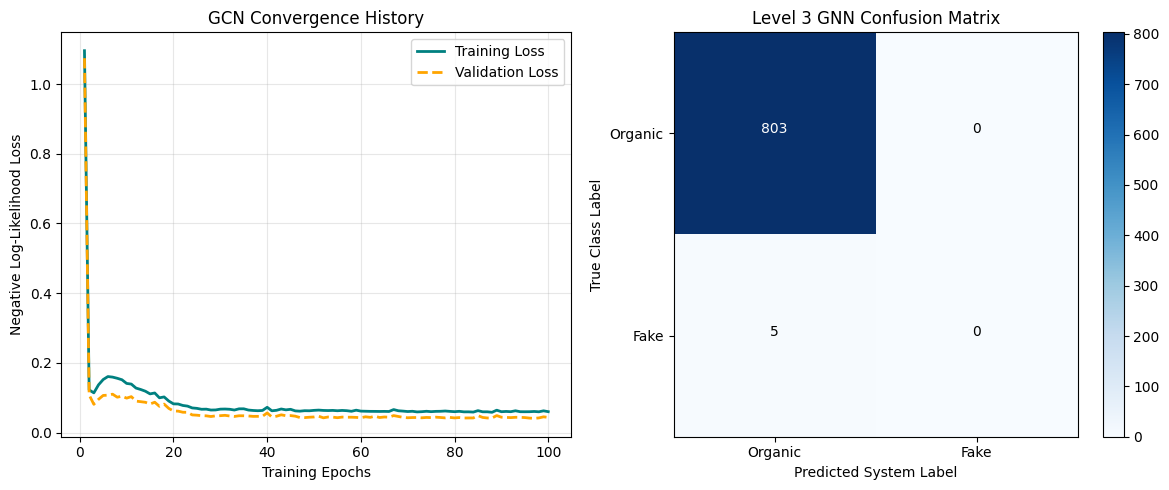

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from node2vec import Node2Vec
from karateclub import DeepWalk

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# Set random seeds for exact reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. DATA LOADING & GRAPH CONSTRUCTION
# ==========================================
# Check both potential file locations automatically
file_path = "Datasets/facebook_combined.txt"
if not os.path.exists(file_path):
    file_path = "facebook_combined.txt"

print(f"Loading network data from: {file_path}...")
textFileData = []
with open(file_path, "r") as textFile:
    for row in textFile:
        parts = row.split()
        textFileData.append((int(parts[0]), int(parts[1])))

# Construct the NetworkX Graph
G = nx.Graph()
G.add_edges_from(textFileData)

print(f"Graph Loaded Successfully!")
print(f"Number of Nodes: {G.number_of_nodes()}")
print(f"Number of Edges: {G.number_of_edges()}")

# ==========================================
# 2. LEVEL 1: GRAPH MINING (Centralities)
# ==========================================
print("\n[Level 1] Calculating Graph Mining Centralities...")
pagerank = nx.pagerank(G)
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

# Convert dictionaries into ordered NumPy arrays matching G.nodes()
pagerank_arr = np.array([pagerank[node] for node in G.nodes()])
degree_arr = np.array([degree_centrality[node] for node in G.nodes()])
closeness_arr = np.array([closeness_centrality[node] for node in G.nodes()])
betweenness_arr = np.array([betweenness_centrality[node] for node in G.nodes()])
eigenvector_arr = np.array([eigenvector_centrality[node] for node in G.nodes()])

# ==========================================
# 3. LEVEL 2: GRAPH EMBEDDINGS
# ==========================================
print("\n[Level 2] Generating Structural Graph Embeddings...")

# A. Truncated SVD Matrix Factorization
print("-> Computing Truncated SVD...")
adj_matrix = nx.to_scipy_sparse_array(G, dtype=float)
svd = TruncatedSVD(n_components=128, random_state=42)
svd_embedding = svd.fit_transform(adj_matrix)

# B. Node2Vec Random Walks
print("-> Computing Node2Vec (This may take a moment)...")
node2vec_process = Node2Vec(G, dimensions=128, walk_length=30, num_walks=200, workers=1)
n2v_model = node2vec_process.fit(window=10, min_count=1, batch_words=4)
# Align Node2Vec embeddings perfectly with G.nodes() order to avoid mismatch errors
n2v_array = np.array([n2v_model.wv[str(node)] for node in G.nodes()])

# C. DeepWalk Embeddings
print("-> Computing DeepWalk...")
deepwalk_model = DeepWalk(walk_length=30, dimensions=128, window_size=5)
deepwalk_model.fit(G)
dw_embeddings = deepwalk_model.get_embedding()

# ==========================================
# 4. FEATURE STACKING & DATA SPLITTING
# ==========================================
print("\nCombining Level 1 and Level 2 features into Node Matrix...")
X_raw = np.column_stack([
      pagerank_arr,
      degree_arr,
      closeness_arr,
      betweenness_arr,
      eigenvector_arr,
      svd_embedding,
      n2v_array,
      dw_embeddings
])
print(f"Feature matrix combined successfully! Shape: {X_raw.shape}")

# Generate labels based on structural anomaly definition (High-degree hubs = Fraud targets)
labels = np.zeros(G.number_of_nodes(), dtype=int)
for node in G.nodes:
    if G.degree(node) > 200:
        labels[node] = 1

# Convert variables to PyTorch Tensors
X = torch.tensor(X_raw, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)
edge_index = torch.tensor(np.array(G.edges()).T, dtype=torch.long)

# Create train/val/test mask splits (60% / 20% / 20%)
num_nodes = X.shape[0]
indices = np.random.permutation(num_nodes)

train_mask = np.zeros(num_nodes, dtype=bool)
val_mask = np.zeros(num_nodes, dtype=bool)
test_mask = np.zeros(num_nodes, dtype=bool)

train_mask[indices[:int(num_nodes * 0.6)]] = True
val_mask[indices[int(num_nodes * 0.6):int(num_nodes * 0.8)]] = True
test_mask[indices[int(num_nodes * 0.8):]] = True

# Pack everything into PyTorch Geometric Data format
dataset = Data(x=X, edge_index=edge_index, y=y)
dataset.train_mask = torch.tensor(train_mask, dtype=torch.bool)
dataset.val_mask = torch.tensor(val_mask, dtype=torch.bool)
dataset.test_mask = torch.tensor(test_mask, dtype=torch.bool)
print("All tensors and dataset masks generated successfully!")

# ==========================================
# 5. LEVEL 3: GRAPH NEURAL NETWORK (GCN)
# ==========================================
print("\n[Level 3] Initializing Graph Convolutional Network Architecture...")

class FakeAccountGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(FakeAccountGCN, self).__init__()
        # Two-layer graph message passing setup
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize model components
model = FakeAccountGCN(in_channels=dataset.x.shape[1], hidden_channels=32, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Arrays to keep track of training history for visualization
train_losses = []
val_losses = []

print("Training Level 3 Graph Neural Network Model...")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    
    out = model(dataset.x, dataset.edge_index)
    loss = F.nll_loss(out[dataset.train_mask], dataset.y[dataset.train_mask])
    loss.backward()
    optimizer.step()
    
    # Evaluate validation loss
    model.eval()
    with torch.no_grad():
        val_loss = F.nll_loss(out[dataset.val_mask], dataset.y[dataset.val_mask])
    
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

print("Model training complete!")

# ==========================================
# 6. SYSTEM EVALUATION & RESULT ANALYSIS
# ==========================================
model.eval()
with torch.no_grad():
    logits = model(dataset.x, dataset.edge_index)
    preds = logits.argmax(dim=1)

# Extract only the test set slices for metric analysis
test_y = dataset.y[dataset.test_mask].numpy()
test_preds = preds[dataset.test_mask].numpy()
test_probs = torch.exp(logits[dataset.test_mask])[:, 1].numpy()

print("\n" + "="*50)
print("             FINAL SYSTEM REPORT ANALYSIS")
print("="*50)
print(classification_report(test_y, test_preds, target_names=["Organic User", "Fake/Fraud Account"]))
print(f"System ROC-AUC Performance Score: {roc_auc_score(test_y, test_probs):.4f}")
print("="*50)

# ==========================================
# 7. VISUALIZATION (COMPULSORY CONSTRAINT)
# ==========================================
print("\nGenerating Performance Visualizations...")
plt.figure(figsize=(12, 5))

# Subplot A: Optimization Learning Curves
plt.subplot(1, 2, 1)
plt.plot(range(1, 101), train_losses, label='Training Loss', color='teal', linewidth=2)
plt.plot(range(1, 101), val_losses, label='Validation Loss', color='orange', linestyle='--', linewidth=2)
plt.title("GCN Convergence History")
plt.xlabel("Training Epochs")
plt.ylabel("Negative Log-Likelihood Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot B: Classification Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(test_y, test_preds)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Level 3 GNN Confusion Matrix")
plt.colorbar()
classes = ['Organic', 'Fake']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.ylabel('True Class Label')
plt.xlabel('Predicted System Label')

# Annotate confusion matrix block counts
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.savefig("detection_performance.png", dpi=300)
print("Plots saved completely as 'detection_performance.png' in your project directory.")
plt.show()